In [6]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
accuracy_score,
precision_score,
recall_score,
f1_score,
roc_auc_score,
confusion_matrix,
classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
RandomForestClassifier,
GradientBoostingClassifier
)

from xgboost import XGBClassifier

import joblib

In [7]:
df = pd.read_csv("Titanic-Dataset.csv")

print(df.head())
print(df.shape)
print(df.info())
print(df.isnull().sum())

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch Embarked            Ticket     Fare Cabin  PassengerId  Pclass  \
0      0        S         A/5 21171   7.2500   NaN            1       3   
1      0        C          PC 17599  71.2833   C85            2       1   
2      0        S  STON/O2. 3101282   7.9250   NaN            3       3   
3      0        S            113803  53.1000  C123            4       1   
4      0        S            373450   8.0500   NaN            5       3   

   Survived  
0         0  
1         1  
2         1  
3         1  
4         0  
(8

Survived
0    549
1    342
Name: count, dtype: int64


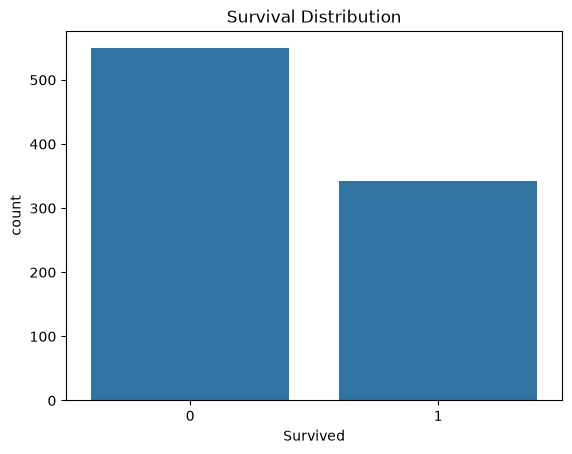

In [8]:
print(df["Survived"].value_counts())

sns.countplot(data=df, x="Survived")
plt.title("Survival Distribution")
plt.show()

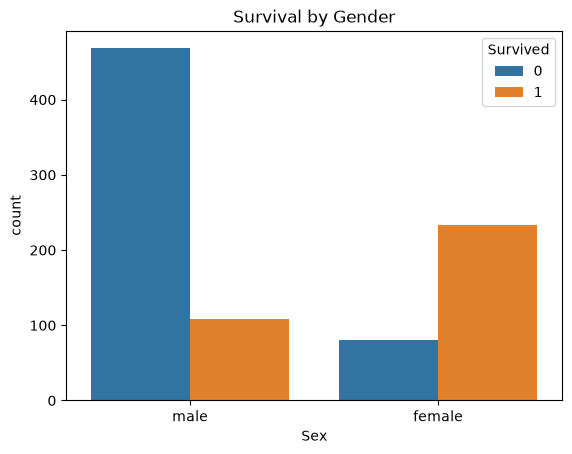

In [9]:
sns.countplot(data=df, x="Sex", hue="Survived")
plt.title("Survival by Gender")
plt.show()

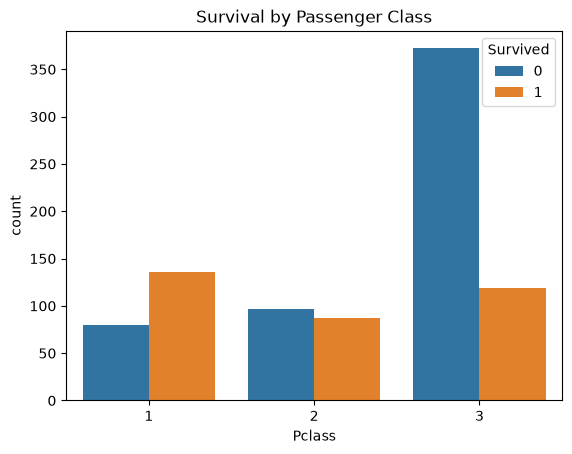

In [10]:
sns.countplot(data=df, x="Pclass", hue="Survived")
plt.title("Survival by Passenger Class")
plt.show()

In [11]:
features = [
"Pclass",
"Sex",
"Age",
"SibSp",
"Parch",
"Fare",
"Embarked"
]

X = df[features]
y = df["Survived"]

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
X,
y,
test_size=0.20,
random_state=42,
stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (712, 7)
Testing data: (179, 7)


In [13]:
numeric_features = [
"Pclass",
"Age",
"SibSp",
"Parch",
"Fare"
]

In [14]:
categorical_features = [
"Sex",
"Embarked"
]

In [15]:
numeric_transformer = Pipeline(
steps=[
("imputer",
SimpleImputer(strategy="median")),
("scaler",
StandardScaler())
]
)

categorical_transformer = Pipeline(
steps=[
("imputer",
SimpleImputer(strategy="most_frequent")),
("encoder",
OneHotEncoder(handle_unknown="ignore"))
]
)

preprocessor = ColumnTransformer(
transformers=[
("num",
numeric_transformer,
numeric_features),

("cat",
categorical_transformer,
categorical_features)
]
)

In [16]:
logistic_model = Pipeline(
steps=[
("preprocessor", preprocessor),
("model", LogisticRegression(
max_iter=1000
))
]
)

In [17]:
decision_tree = Pipeline(
steps=[
("preprocessor", preprocessor),
("model", DecisionTreeClassifier(
random_state=42,
max_depth=5
))
]
)

In [18]:
random_forest = Pipeline(
steps=[
("preprocessor", preprocessor),
("model", RandomForestClassifier(
n_estimators=300,
random_state=42
))
]
)

In [19]:
gradient_boosting = Pipeline(
steps=[
("preprocessor", preprocessor),
("model", GradientBoostingClassifier(
random_state=42
))
]
)

In [20]:
xgb_model = Pipeline(
steps=[
("preprocessor", preprocessor),
("model", XGBClassifier(
n_estimators=300,
max_depth=4,
learning_rate=0.05,
subsample=0.8,
colsample_bytree=0.8,
eval_metric="logloss",
random_state=42
))
]
)

In [21]:
ml_models = {
"Logistic Regression": logistic_model,
"Decision Tree": decision_tree,
"Random Forest": random_forest,
"Gradient Boosting": gradient_boosting,
"XGBoost": xgb_model
}

In [22]:
ml_results = []

for name, model in ml_models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    ml_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

ml_results_df = pd.DataFrame(ml_results)

print(ml_results_df)

                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
0  Logistic Regression  0.804469   0.793103  0.666667  0.724409  0.843742
1        Decision Tree  0.765363   0.754717  0.579710  0.655738  0.797101
2        Random Forest  0.810056   0.796610  0.681159  0.734375  0.828722
3    Gradient Boosting  0.798883   0.789474  0.652174  0.714286  0.817918
4              XGBoost  0.787709   0.762712  0.652174  0.703125  0.812846


In [23]:
print(
ml_results_df.sort_values(
by="F1 Score",
ascending=False
)
)

                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
2        Random Forest  0.810056   0.796610  0.681159  0.734375  0.828722
0  Logistic Regression  0.804469   0.793103  0.666667  0.724409  0.843742
3    Gradient Boosting  0.798883   0.789474  0.652174  0.714286  0.817918
4              XGBoost  0.787709   0.762712  0.652174  0.703125  0.812846
1        Decision Tree  0.765363   0.754717  0.579710  0.655738  0.797101


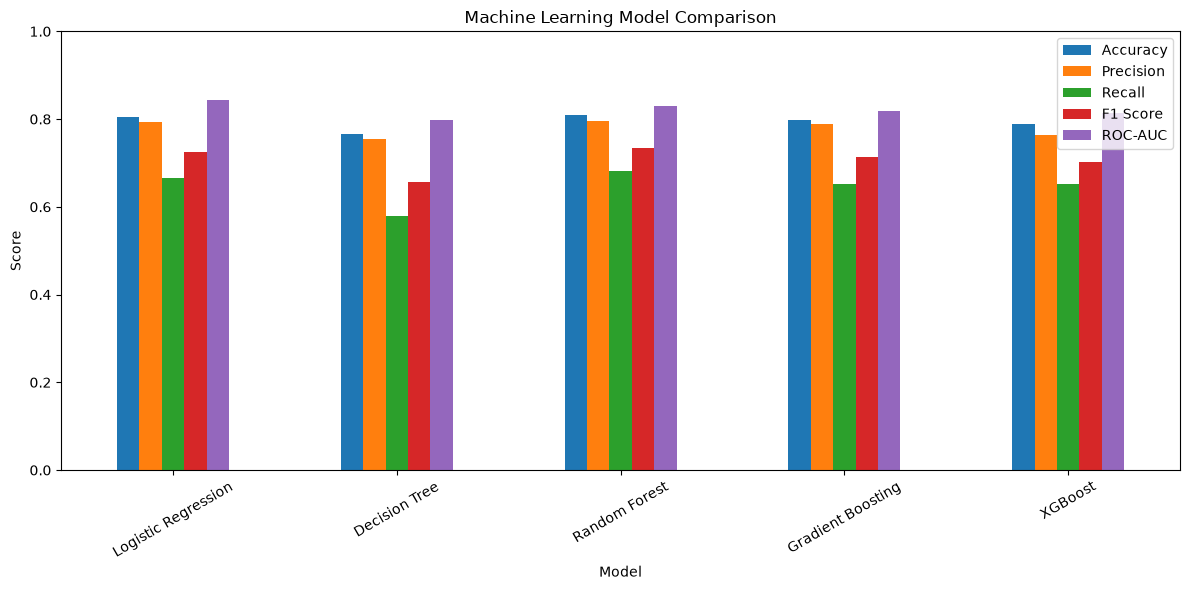

In [24]:
ml_results_df.set_index("Model")[
["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]
].plot(
kind="bar",
figsize=(12, 6)
)

plt.title("Machine Learning Model Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [25]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

dl_numeric = Pipeline([
("imputer", SimpleImputer(strategy="median")),
("scaler", StandardScaler())
])

dl_categorical = Pipeline([
("imputer",
SimpleImputer(strategy="most_frequent")),
("encoder", OneHotEncoder(handle_unknown="ignore"))
])

dl_preprocessor = ColumnTransformer([
("num", dl_numeric, numeric_features),
("cat", dl_categorical, categorical_features)
])

X_train_dl = dl_preprocessor.fit_transform(X_train)
X_test_dl = dl_preprocessor.transform(X_test)

print(X_train_dl.shape)

(712, 10)


In [26]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

ann_model = Sequential([
Dense(
64,
activation="relu",
input_shape=(X_train_dl.shape[1],)
),

Dropout(0.30),

Dense(
32,
activation="relu"
),

Dropout(0.20),

Dense(
16,
activation="relu"
),

Dense(
1,
activation="sigmoid"
)
])

ann_model.compile(
optimizer="adam",
loss="binary_crossentropy",
metrics=["accuracy"]
)

ann_history = ann_model.fit(
X_train_dl,
y_train,
validation_split=0.20,
epochs=50,
batch_size=32,
verbose=1
)

c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 6s 71ms/step - accuracy: 0.6485 - loss: 0.6430 - val_accuracy: 0.6853 - val_loss: 0.6170
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6960 - loss: 0.5965 - val_accuracy: 0.7273 - val_loss: 0.5591
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7575 - loss: 0.5344 - val_accuracy: 0.7622 - val_loss: 0.5186
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.7786 - loss: 0.5072 - val_accuracy: 0.7832 - val_loss: 0.4901
Epoch 5/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.7663 - loss: 0.4946 - val_accuracy: 0.7832 - val_loss: 0.4688
Epoch 6/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.7838 - loss: 0.4684 - val_accuracy: 0.7972 - val_loss: 0.4564
Epoch 7/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.8032 - loss: 0.4599 - val_accuracy: 0.8182 - val_loss: 0.4517
Epoch 8/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8049 - loss: 0.4576 - val_accuracy: 0.8042 - v

In [27]:
ann_prob = ann_model.predict(
X_test_dl
).ravel()

ann_pred = (
ann_prob >= 0.5
).astype(int)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


In [28]:
ann_results = {
"Model": "ANN",
"Accuracy": accuracy_score(
y_test,
ann_pred
),
"Precision": precision_score(
y_test,
ann_pred
),
"Recall": recall_score(
y_test,
ann_pred
),
"F1 Score": f1_score(
y_test,
ann_pred
),
"ROC-AUC": roc_auc_score(
y_test,
ann_prob
)
}

print(ann_results)

{'Model': 'ANN', 'Accuracy': 0.7988826815642458, 'Precision': 0.8367346938775511, 'Recall': 0.5942028985507246, 'F1 Score': 0.6949152542372882, 'ROC-AUC': 0.8538866930171277}


In [29]:
X_train_cnn = X_train_dl.reshape(
X_train_dl.shape[0],
X_train_dl.shape[1],
1
)

X_test_cnn = X_test_dl.reshape(
X_test_dl.shape[0],
X_test_dl.shape[1],
1
)

In [30]:
from tensorflow.keras.layers import (
Conv1D,
MaxPooling1D,
Flatten
)

cnn_model = Sequential([
Conv1D(
32,
kernel_size=3,
activation="relu",
input_shape=(
X_train_cnn.shape[1],
1
)
),

MaxPooling1D(pool_size=2),

Conv1D(
64,
kernel_size=3,
activation="relu"
),

Flatten(),

Dense(
32,
activation="relu"
),

Dropout(0.30),

Dense(
1,
activation="sigmoid"
)
])

cnn_model.compile(
optimizer="adam",
loss="binary_crossentropy",
metrics=["accuracy"]
)

cnn_history = cnn_model.fit(
X_train_cnn,
y_train,
validation_split=0.20,
epochs=50,
batch_size=32,
verbose=1
)

c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 5s 63ms/step - accuracy: 0.6327 - loss: 0.6453 - val_accuracy: 0.6643 - val_loss: 0.5992
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7276 - loss: 0.5588 - val_accuracy: 0.7622 - val_loss: 0.5244
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7592 - loss: 0.5114 - val_accuracy: 0.8042 - val_loss: 0.4852
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.7786 - loss: 0.4858 - val_accuracy: 0.7902 - val_loss: 0.4693
Epoch 5/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.7926 - loss: 0.4778 - val_accuracy: 0.8112 - val_loss: 0.4696
Epoch 6/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.7838 - loss: 0.4833 - val_accuracy: 0.7972 - val_loss: 0.4642
Epoch 7/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7979 - loss: 0.4666 - val_accuracy: 0.7972 - val_loss: 0.4607
Epoch 8/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.7944 - loss: 0.4504 - val_accuracy: 0.8042 - v

In [31]:
cnn_prob = cnn_model.predict(
X_test_cnn
).ravel()

cnn_pred = (
cnn_prob >= 0.5
).astype(int)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


In [32]:
cnn_results = {
"Model": "1D CNN",
"Accuracy": accuracy_score(
y_test,
cnn_pred
),
"Precision": precision_score(
y_test,
cnn_pred
),
"Recall": recall_score(
y_test,
cnn_pred
),
"F1 Score": f1_score(
y_test,
cnn_pred
),
"ROC-AUC": roc_auc_score(
y_test,
cnn_prob
)
}

print(cnn_results)

{'Model': '1D CNN', 'Accuracy': 0.7821229050279329, 'Precision': 0.7142857142857143, 'Recall': 0.7246376811594203, 'F1 Score': 0.7194244604316546, 'ROC-AUC': 0.8454545454545455}


In [33]:
dl_results_df = pd.DataFrame([
ann_results,
cnn_results
])

all_results = pd.concat(
[
ml_results_df,
dl_results_df
],
ignore_index=True
)

In [34]:
all_results = all_results.sort_values(
by="F1 Score",
ascending=False
)

print(all_results)

                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
2        Random Forest  0.810056   0.796610  0.681159  0.734375  0.828722
0  Logistic Regression  0.804469   0.793103  0.666667  0.724409  0.843742
6               1D CNN  0.782123   0.714286  0.724638  0.719424  0.845455
3    Gradient Boosting  0.798883   0.789474  0.652174  0.714286  0.817918
4              XGBoost  0.787709   0.762712  0.652174  0.703125  0.812846
5                  ANN  0.798883   0.836735  0.594203  0.694915  0.853887
1        Decision Tree  0.765363   0.754717  0.579710  0.655738  0.797101


In [35]:
best_model_name = all_results.iloc[0]["Model"]

print(
"Best model based on F1 Score:",
best_model_name
)

Best model based on F1 Score: Random Forest


In [36]:
best_ml_model = ml_models[best_model_name]

joblib.dump(
    best_ml_model,
    "titanic_best_model.pkl"
)

['titanic_best_model.pkl']

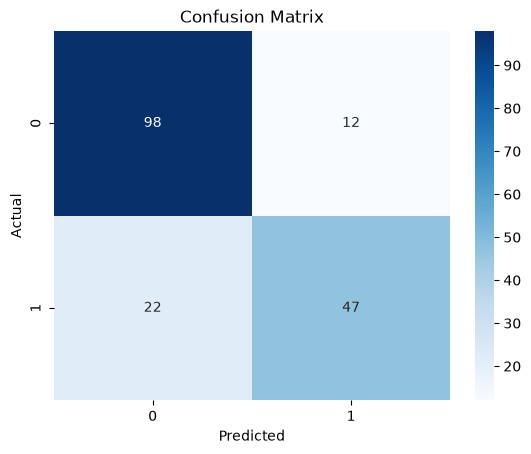

In [37]:
best_ml_model.fit(X_train, y_train)

y_pred = best_ml_model.predict(X_test)

cm = confusion_matrix(
    y_test,
    y_pred
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [38]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.82      0.89      0.85       110
           1       0.80      0.68      0.73        69

    accuracy                           0.81       179
   macro avg       0.81      0.79      0.79       179
weighted avg       0.81      0.81      0.81       179



In [39]:
rf = random_forest.named_steps["model"]

importance = rf.feature_importances_

print(importance)

[0.08724757 0.24386857 0.04653117 0.03852677 0.25748962 0.13645728
 0.15371693 0.01209837 0.00773332 0.01633041]
